In [ ]:
import pandas as pd
pd.read_csv('../stats-all-latest.csv').to_pickle('../stats-all-latest.pkl')

1


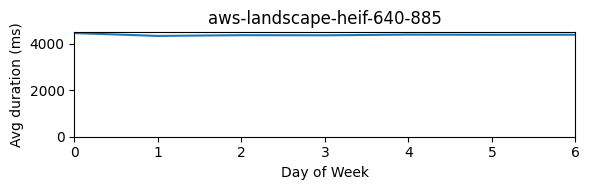

2


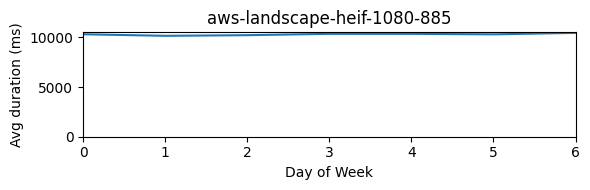

3


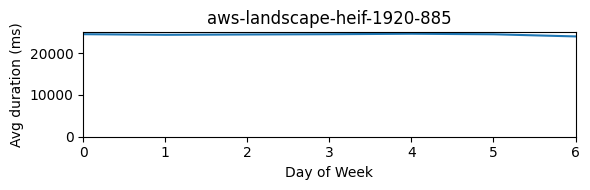

4


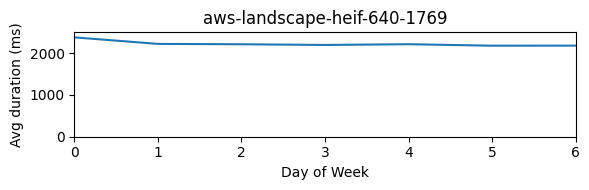

5


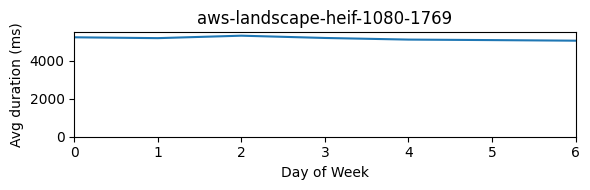

6


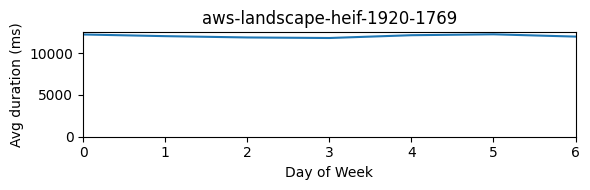

7


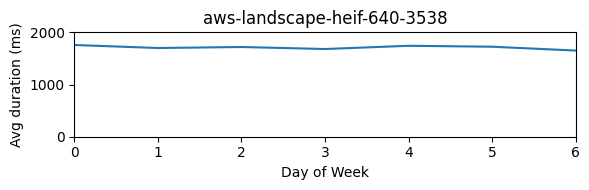

8


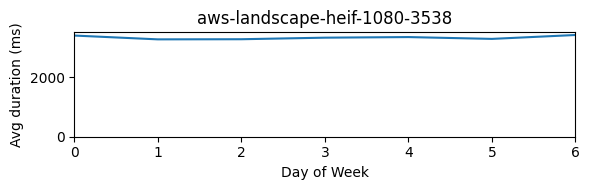

9


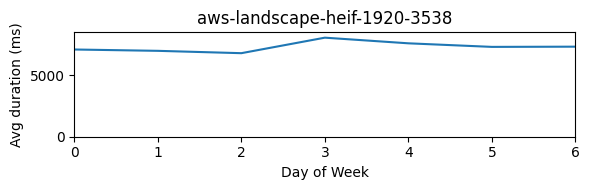

10


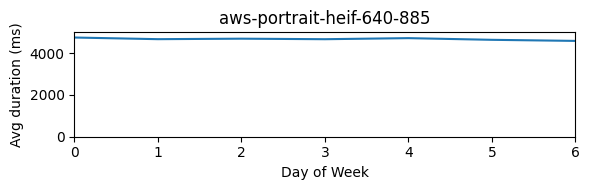

11


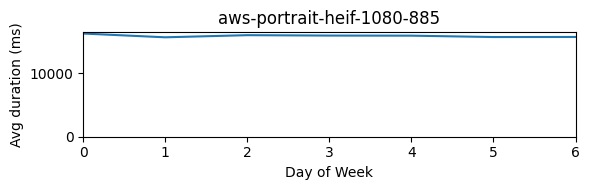

12


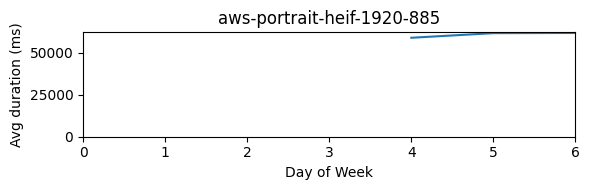

13


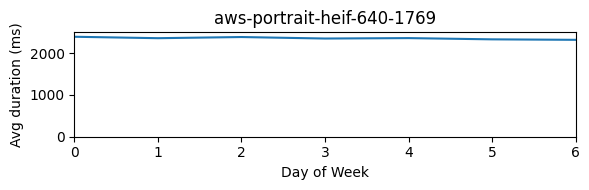

14


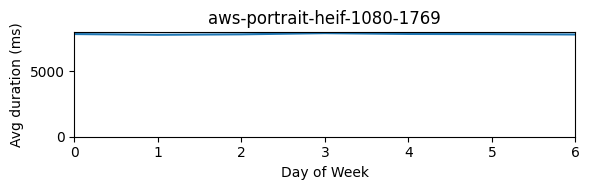

15


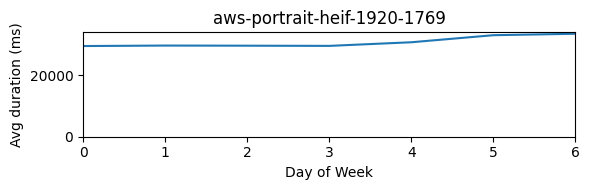

16


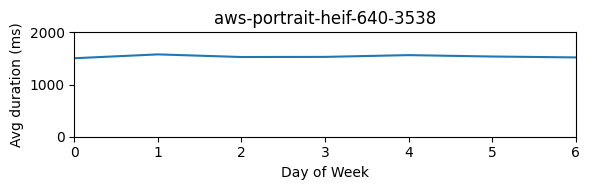

17


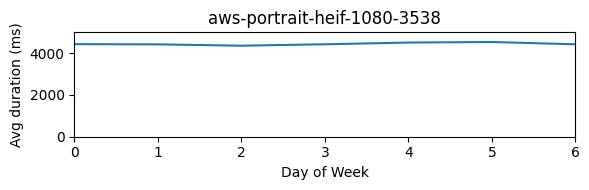

18


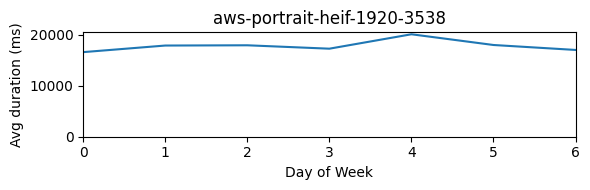

19


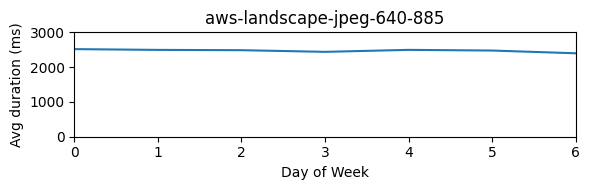

20


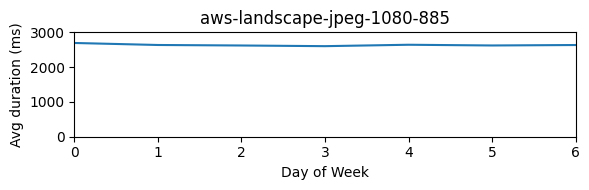

21


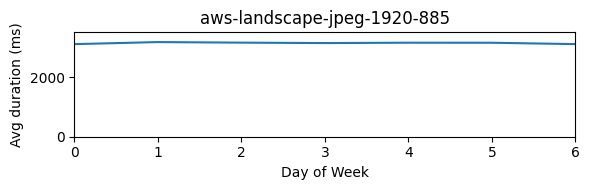

22


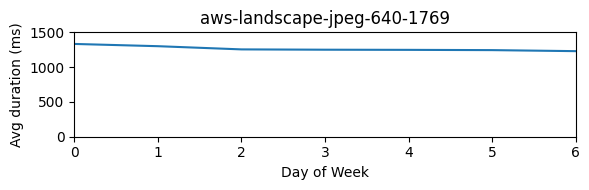

23


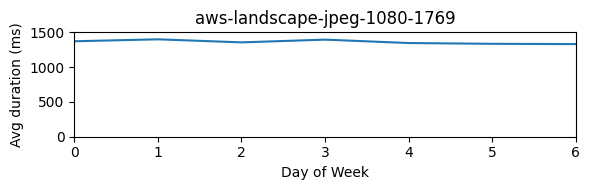

24


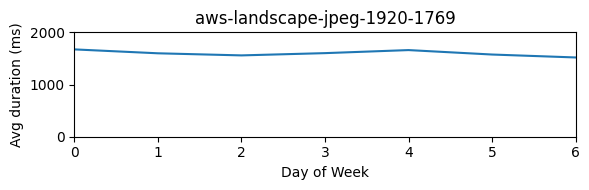

25


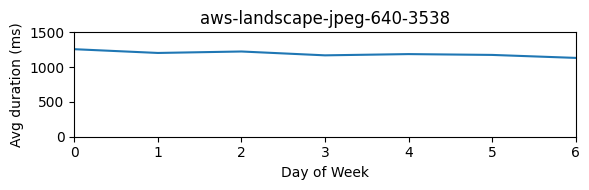

26


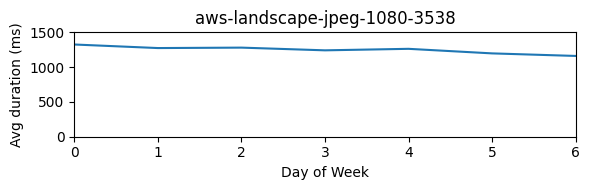

27


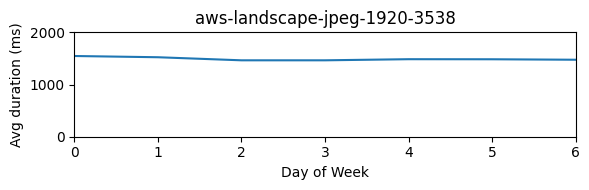

28


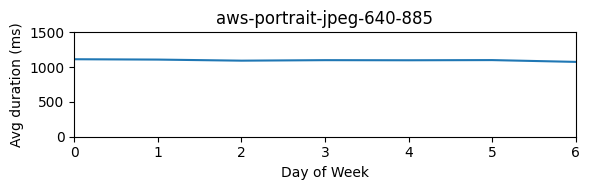

29


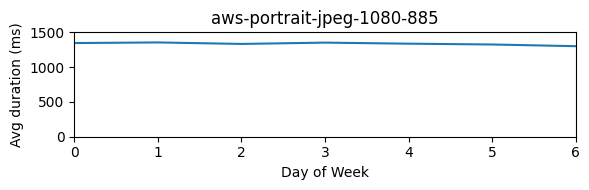

30


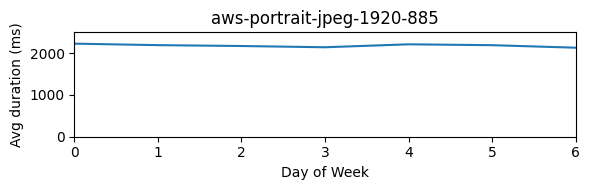

31


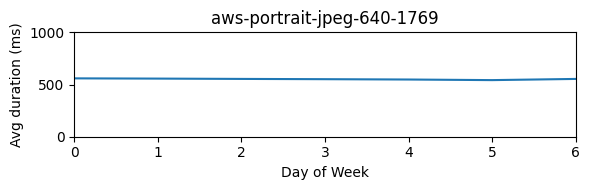

32


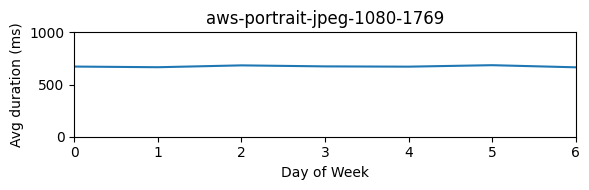

33


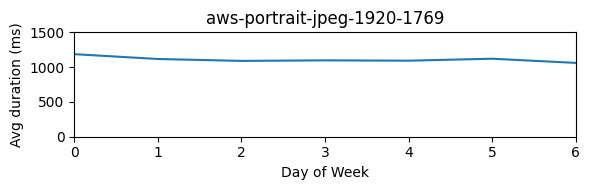

34


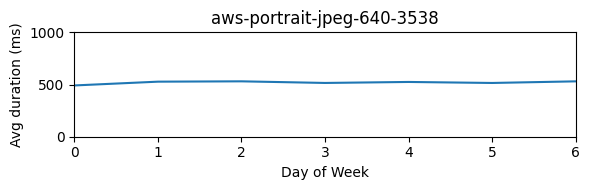

35


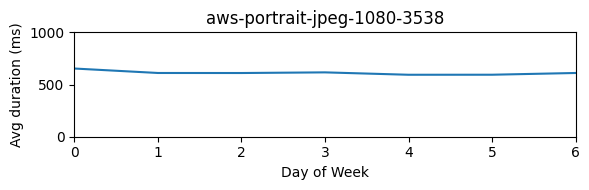

36


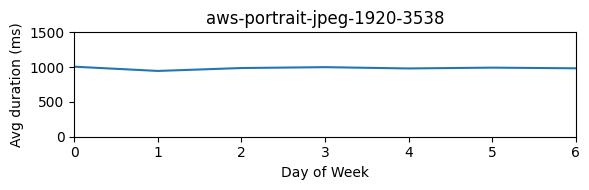

37


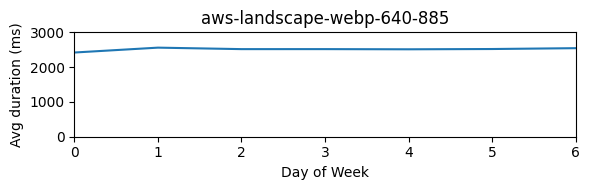

38


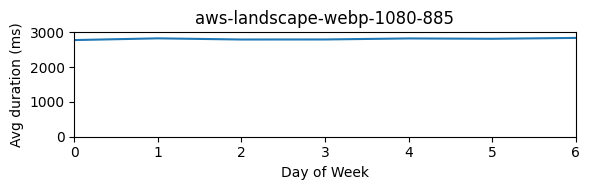

39


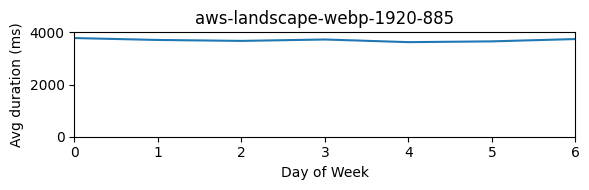

40


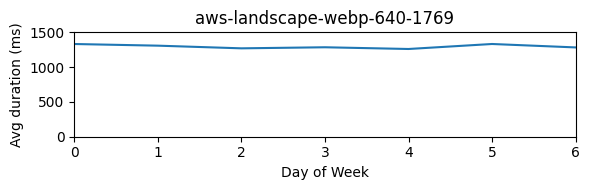

41


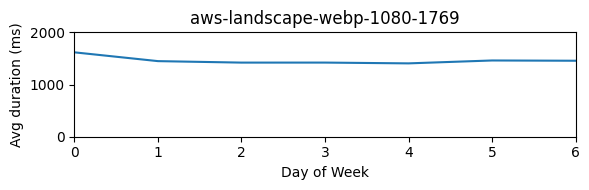

42


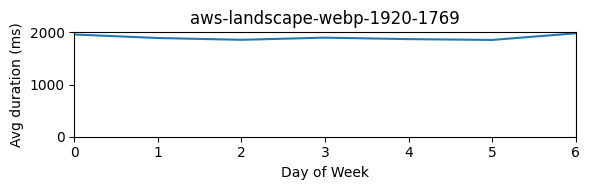

43


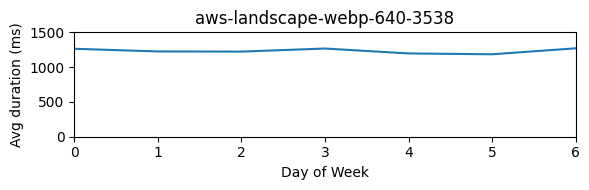

44


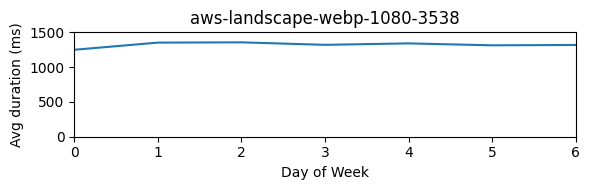

45


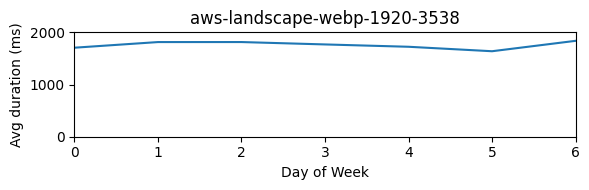

46


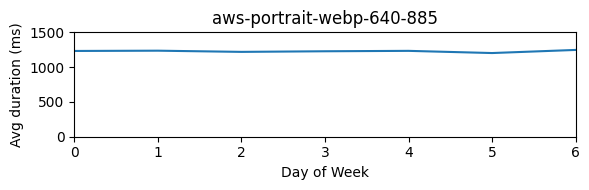

47


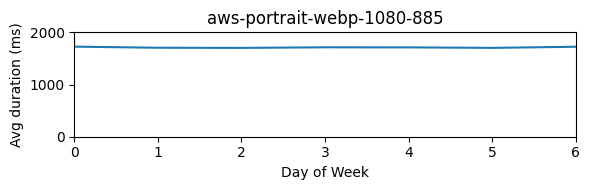

48


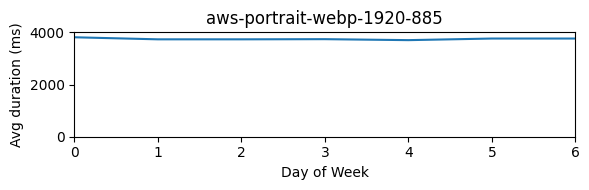

49


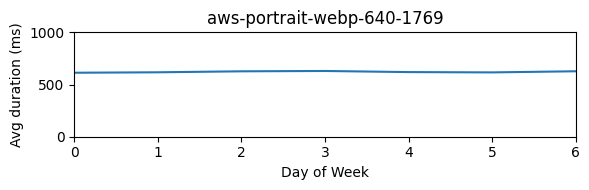

50


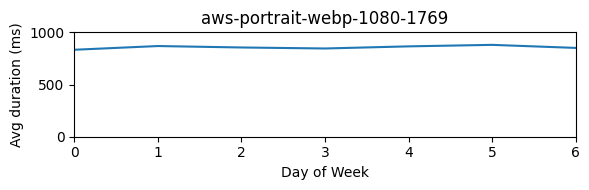

51


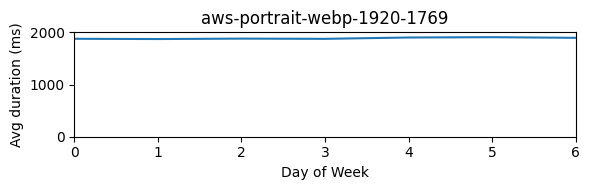

52


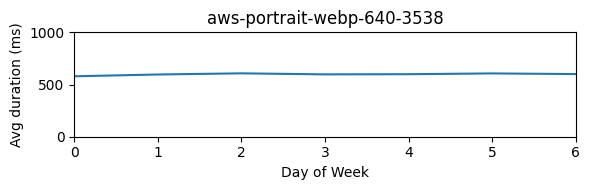

53


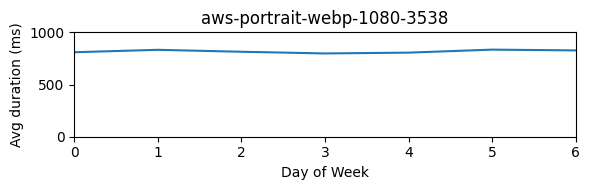

54


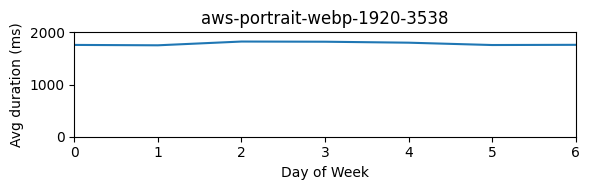

55


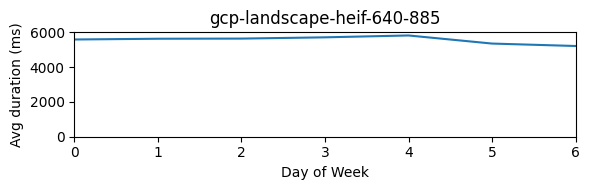

56


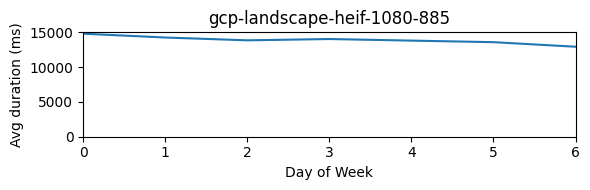

57


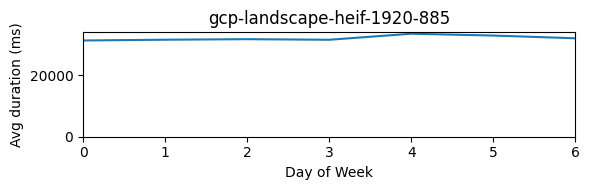

58


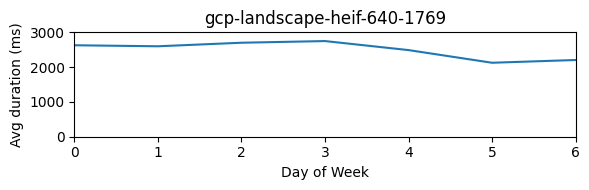

59


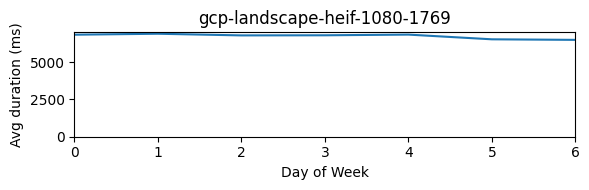

60


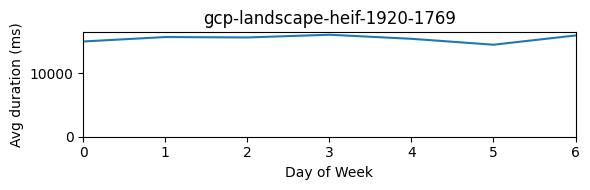

61


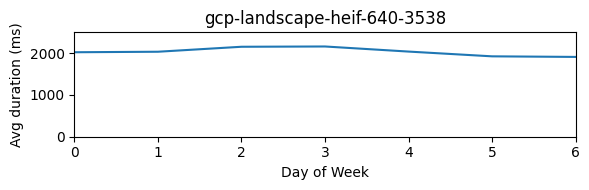

62


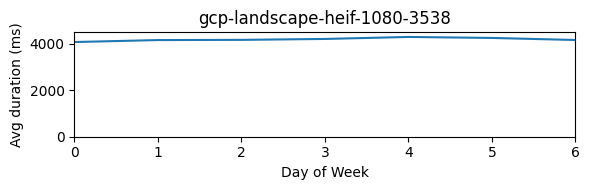

63


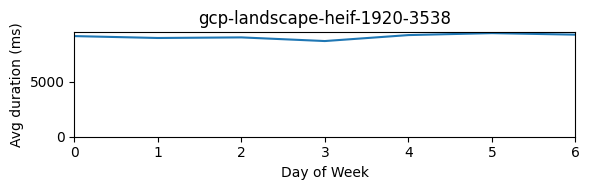

64


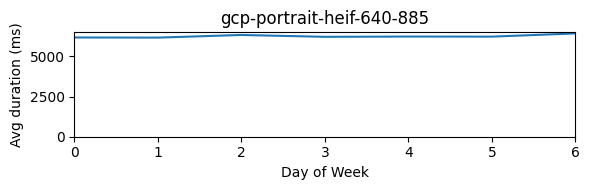

65


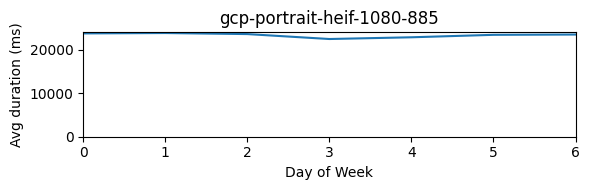

66


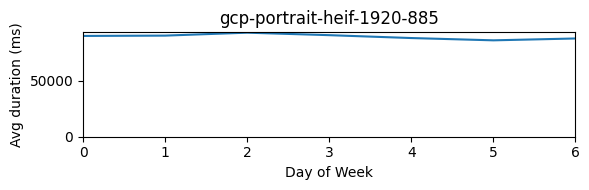

67


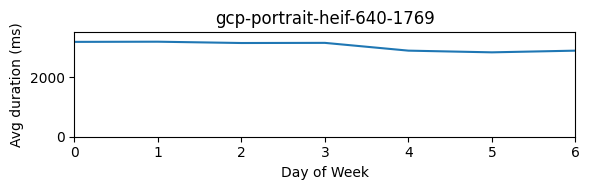

68


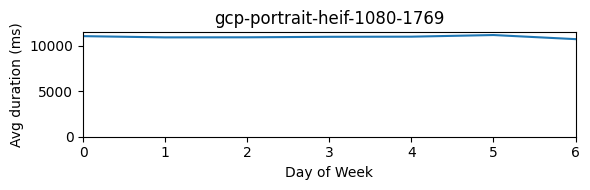

69


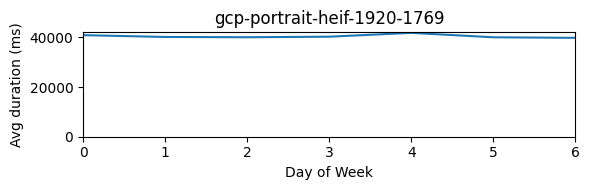

70


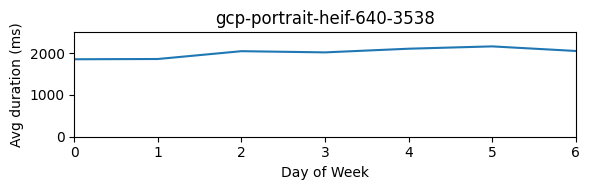

71


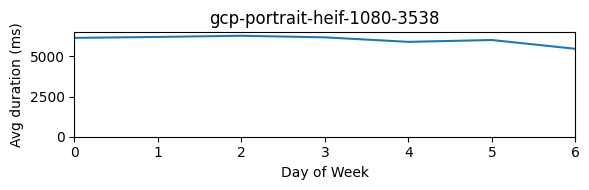

72


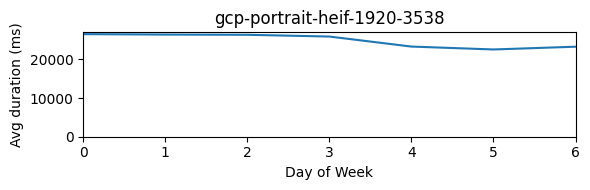

73


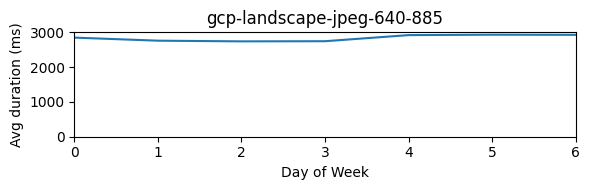

74


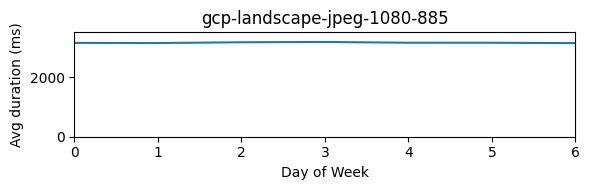

75


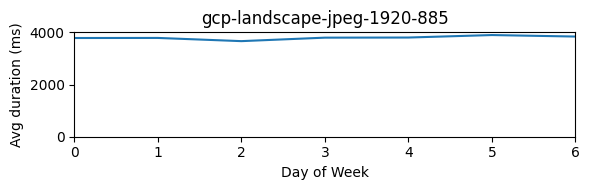

76


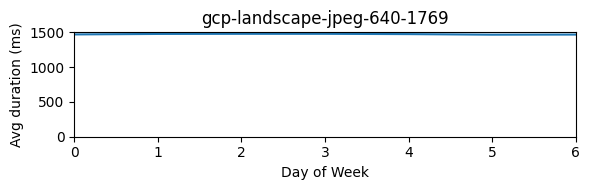

77


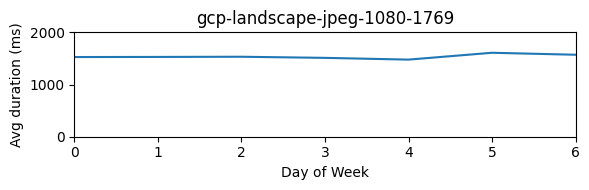

78


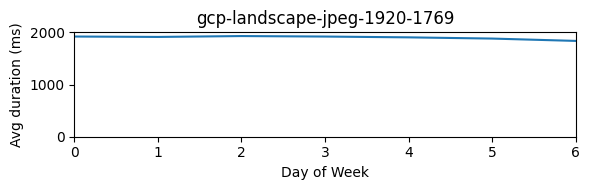

79


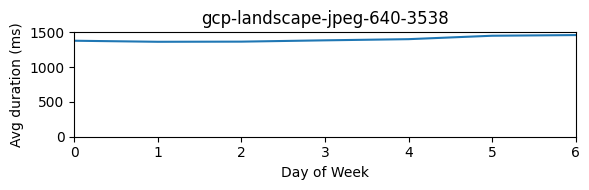

80


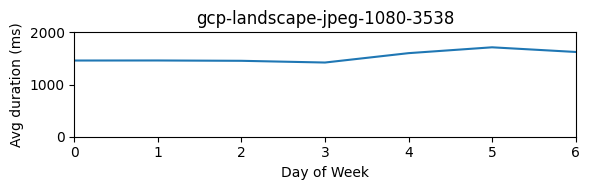

81


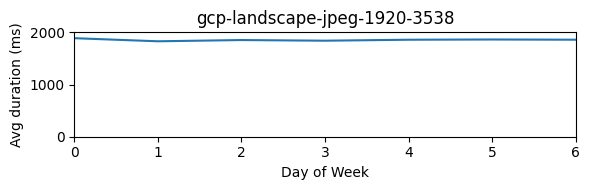

82


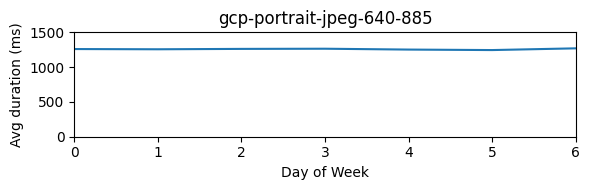

83


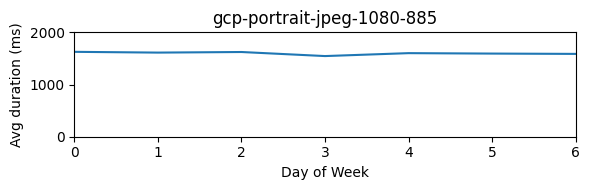

84


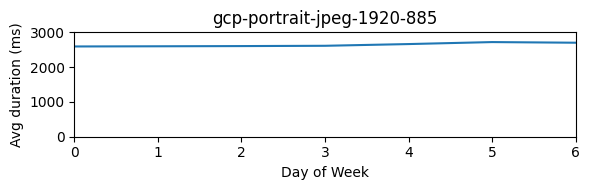

85


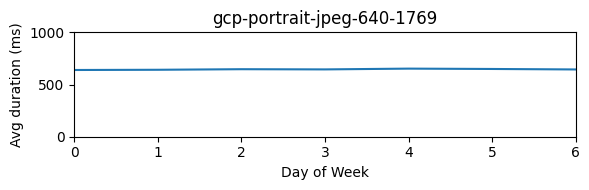

86


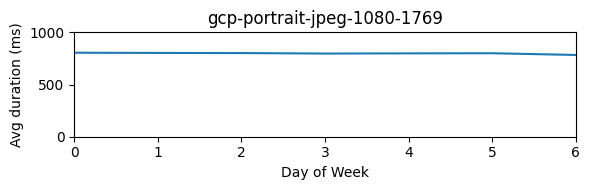

87


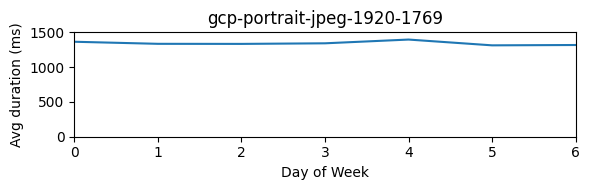

88


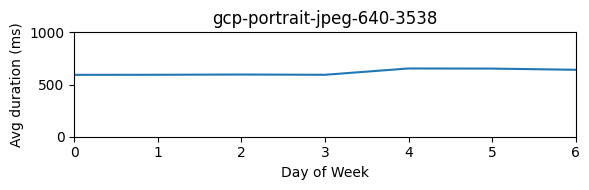

89


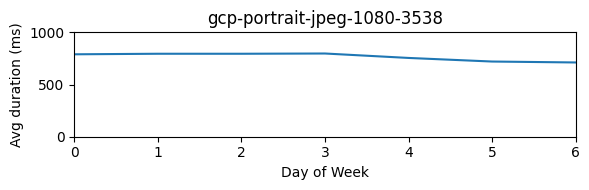

90


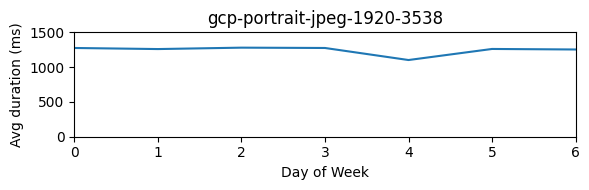

91


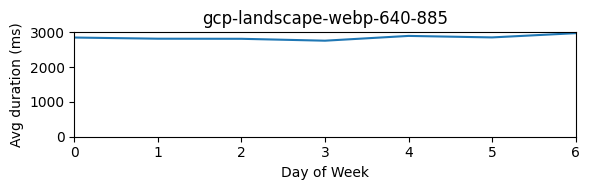

92


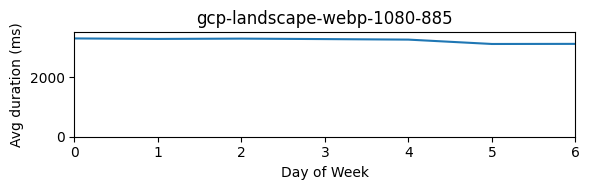

93


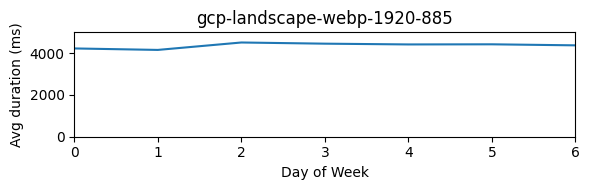

94


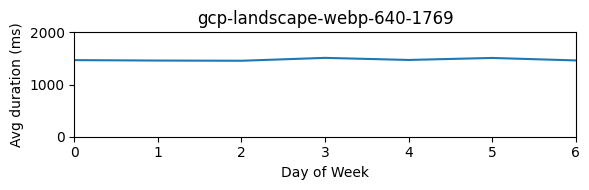

95


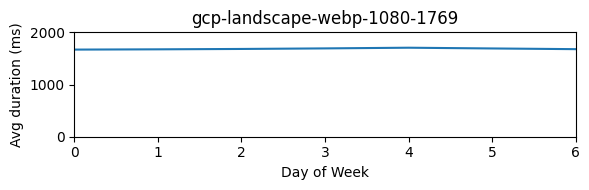

96


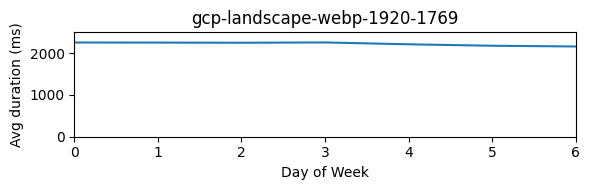

97


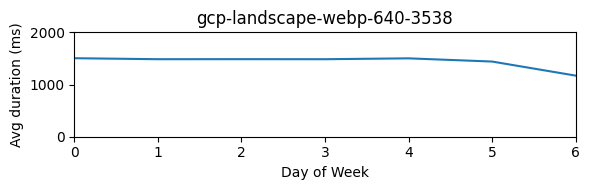

98


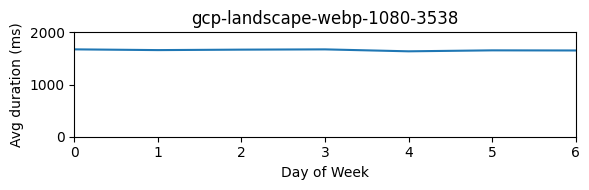

99


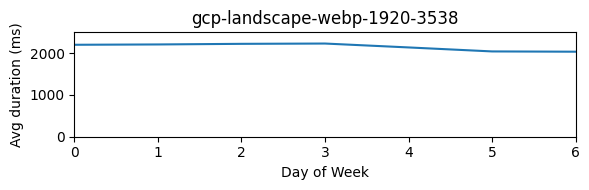

100


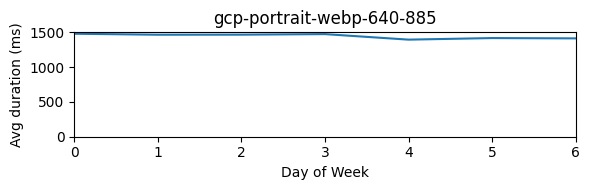

101


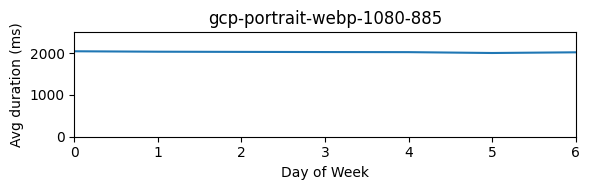

102


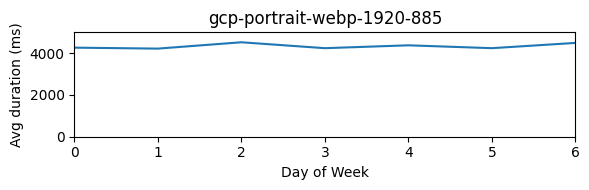

103


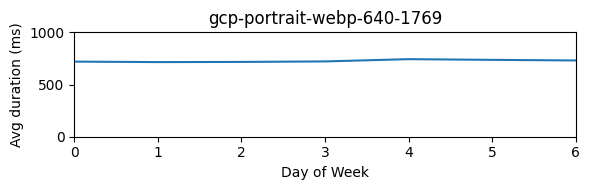

104


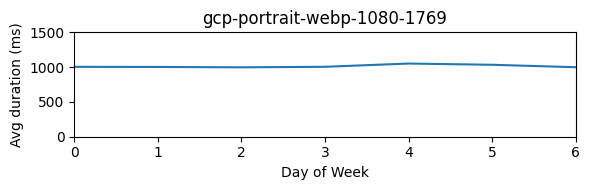

105


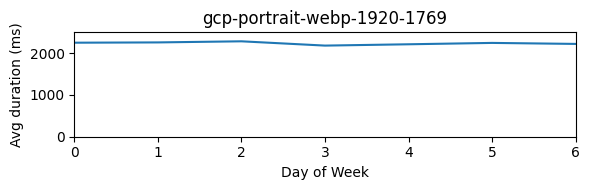

106


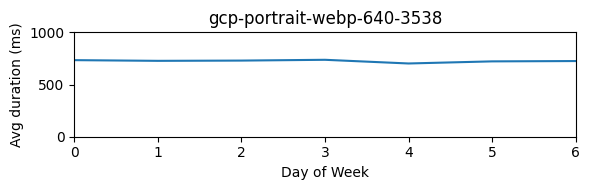

107


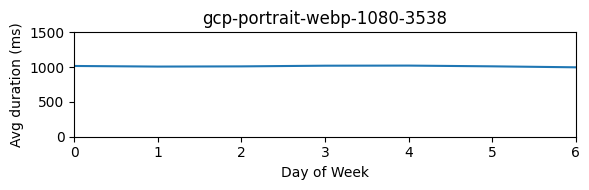

108


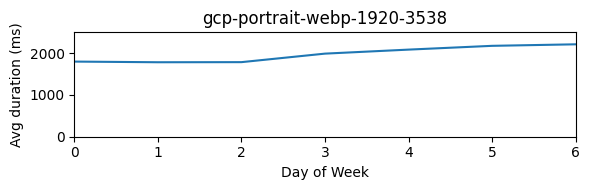

In [ ]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np

pd.set_option('display.width', 1000)
df = pd.read_pickle('../stats-all-latest.pkl')

# Convert the 'isoDate' column to datetime objects
df['isoDate'] = pd.to_datetime(df['!isoDate'])
df = df.set_index("isoDate").sort_index()

# Extract the day of week from the 'isoDate'
df["time_agg"] = df.index.day_of_week

# Filter data for particular output format
# df = df[df['outputFormat'] == 'jpeg']

# Group by the specified columns and calculate the mean 'durationImageProcessingMs'
# grouped_df = df.groupby(['imageName', 'outputWidth', 'providerMemoryAssociated', 'how'])['durationImageProcessingMs'].agg(trimmed_mean).reset_index()
mean_processing_time = df.groupby(['imageName', 'outputFormat', 'outputWidth', 'providerMemoryAssociated', 'providerName', 'time_agg'])['durationProcessingMs'].mean().reset_index()

index=1
# Plotting the results
for name, group in mean_processing_time.groupby(['providerName', 'outputFormat', 'imageName', 'providerMemoryAssociated', 'outputWidth']):
    print(f"{index}")
    index+=1
    fig, ax = plt.subplots(figsize=(6, 2))
    lbl_provider, lbl_memory, lbl_image, lbl_width, lbl_format = name
    ax.plot(group['time_agg'], group['durationProcessingMs'])
    ax.set_xlabel("Day of Week")
    ax.set_ylabel("Avg duration (ms)")
    ax.set_title(f"{lbl_provider}-{lbl_image}-{lbl_memory}-{lbl_format}-{lbl_width}")
    ax.set_xlim(0, 6)

    # Calculate ylim
    # round = 500
    # ymin = math.floor(group['durationProcessingMs'].min() / round) * round
    # ymax = math.ceil(group['durationProcessingMs'].max() / round) * round
    # ax.set_ylim(0, ymax)

    plt.tight_layout()
    plt.show()